# HW08-09 — PyTorch MLP: регуляризация и оптимизация обучения

Этот ноутбук соответствует структуре и требованиям задания:

- датасет через `torchvision`
- воспроизводимое разбиение `train/val`
- MLP на `PyTorch`
- эксперименты **E1–E4** (регуляризация и early stopping)
- эксперименты **O1–O3** (learning rate, SGD+momentum, weight decay)
- сохранение артефактов в `homeworks/HW08-09/artifacts/`

> По умолчанию выбран **EMNIST**. При желании можно переключить на `KMNIST` или `CIFAR10` в конфигурации ниже.


In [17]:
import csv
import json
import os
import random
import sys
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print("Python:", sys.version.split()[0])
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)


Python: 3.12.7
torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [18]:
# =========================
# Конфигурация эксперимента
# =========================

DATASET_NAME = "EMNIST"   # "KMNIST" | "EMNIST" | "CIFAR10"
SEED = 42
BATCH_SIZE = 128
NUM_WORKERS = 0

# Эпохи подобраны так, чтобы ноутбук было удобно запускать и на CPU
EPOCHS_PART_A = 12
EPOCHS_E4_MAX = 20
EPOCHS_LR_DIAG = 6
EPOCHS_O3 = 10

BASE_LR = 1e-3
EARLY_STOPPING_PATIENCE = 4

# Архитектура по умолчанию.
BASE_HIDDEN_SIZES = (256, 128)

cwd = Path.cwd()
if cwd.name == "HW08-09" and cwd.parent.name == "homeworks":
    REPO_ROOT = cwd.parent.parent
elif (cwd / "homeworks").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd

BASE_DIR = REPO_ROOT / "homeworks" / "HW08-09"
ARTIFACTS_DIR = BASE_DIR / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
DATA_ROOT = REPO_ROOT / "data"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

print("REPO_ROOT:", REPO_ROOT.resolve())
print("BASE_DIR:", BASE_DIR.resolve())
print("DATA_ROOT:", DATA_ROOT.resolve())


REPO_ROOT: C:\Dev\mirea-ai
BASE_DIR: C:\Dev\mirea-ai\homeworks\HW08-09
DATA_ROOT: C:\Dev\mirea-ai\data


In [19]:
# =========================
# Воспроизводимость и device
# =========================

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [20]:
# =========================
# Загрузка датасета
# =========================

def build_transform(dataset_name: str):
    return transforms.ToTensor()


def load_dataset(dataset_name: str, data_root: Path):
    transform = build_transform(dataset_name)

    if dataset_name == "KMNIST":
        train_dataset_full = datasets.KMNIST(root=data_root, train=True, download=True, transform=transform)
        test_dataset = datasets.KMNIST(root=data_root, train=False, download=True, transform=transform)
        input_shape = (1, 28, 28)
        num_classes = 10

    elif dataset_name == "EMNIST":
        train_dataset_full = datasets.EMNIST(
            root=data_root, split="balanced", train=True, download=True, transform=transform
        )
        test_dataset = datasets.EMNIST(
            root=data_root, split="balanced", train=False, download=True, transform=transform
        )
        input_shape = (1, 28, 28)
        num_classes = 47

    elif dataset_name == "CIFAR10":
        train_dataset_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=transform)
        test_dataset = datasets.CIFAR10(root=data_root, train=False, download=True, transform=transform)
        input_shape = (3, 32, 32)
        num_classes = 10

    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    input_dim = int(np.prod(input_shape))
    return train_dataset_full, test_dataset, input_shape, input_dim, num_classes, transform


train_dataset_full, test_dataset, input_shape, input_dim, num_classes, transform = load_dataset(
    DATASET_NAME, DATA_ROOT
)

train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=split_generator,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Dataset:", DATASET_NAME)
print("Input shape:", input_shape)
print("Input dim:", input_dim)
print("Num classes:", num_classes)
print("Train / Val / Test:", len(train_dataset), len(val_dataset), len(test_dataset))


Dataset: EMNIST
Input shape: (1, 28, 28)
Input dim: 784
Num classes: 47
Train / Val / Test: 90240 22560 18800


In [21]:
# =========================
# Sanity-check батча
# =========================

x_batch, y_batch = next(iter(train_loader))
print("x.shape:", tuple(x_batch.shape))
print("y.shape:", tuple(y_batch.shape))
print("x.min():", float(x_batch.min()))
print("x.max():", float(x_batch.max()))
print("y dtype:", y_batch.dtype)
print("labels sample:", y_batch[:10].tolist())


x.shape: (128, 1, 28, 28)
y.shape: (128,)
x.min(): 0.0
x.max(): 1.0
y dtype: torch.int64
labels sample: [32, 3, 36, 29, 28, 23, 39, 2, 9, 10]


## MLP, train/eval цикл и вспомогательные функции


In [22]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_sizes=(256, 128),
        num_classes: int = 10,
        dropout: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        layers = [nn.Flatten()]
        prev_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def summarize_model(hidden_sizes, dropout, use_batchnorm):
    return (
        f"hidden_sizes={list(hidden_sizes)}; activation=ReLU; "
        f"dropout={dropout}; batchnorm={use_batchnorm}"
    )


In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_examples += x.size(0)

    return total_loss / total_examples, total_correct / total_examples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_examples += x.size(0)

    return total_loss / total_examples, total_correct / total_examples


class EarlyStopping:
    def __init__(self, patience=4, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.best_state_dict = None
        self.counter = 0

    def step(self, score, model):
        improved = False

        if self.best_score is None:
            improved = True
        elif self.mode == "max" and score > self.best_score:
            improved = True
        elif self.mode == "min" and score < self.best_score:
            improved = True

        if improved:
            self.best_score = score
            self.best_state_dict = deepcopy(model.state_dict())
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience


In [24]:
def run_experiment(
    experiment_id: str,
    model: nn.Module,
    train_loader,
    val_loader,
    device,
    optimizer_name: str = "Adam",
    lr: float = 1e-3,
    momentum: float = 0.0,
    weight_decay: float = 0.0,
    epochs: int = 10,
    early_stopping=None,
    dataset_name: str = "KMNIST",
    seed: int = 42,
    model_summary: str = "",
):
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay,
        )
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    model = model.to(device)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state_dict = deepcopy(model.state_dict())
    epochs_trained = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = deepcopy(model.state_dict())

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        epochs_trained += 1

        print(
            f"{experiment_id} | epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
        )

        if early_stopping is not None:
            should_stop = early_stopping.step(val_acc, model)
            if should_stop:
                print(f"{experiment_id} | early stopping at epoch {epoch}")
                best_state_dict = deepcopy(early_stopping.best_state_dict)
                best_val_acc = float(early_stopping.best_score)
                break

    model.load_state_dict(best_state_dict)

    run_row = {
        "experiment_id": experiment_id,
        "dataset": dataset_name,
        "seed": seed,
        "model_summary": model_summary,
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum if optimizer_name == "SGD" else 0.0,
        "weight_decay": weight_decay,
        "epochs_trained": epochs_trained,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss,
    }

    return model, history, run_row


## Часть A (S08): регуляризация и переобучение — E1–E4


In [ ]:
runs = []

# E1: base
e1_cfg = {
    "hidden_sizes": BASE_HIDDEN_SIZES,
    "dropout": 0.0,
    "use_batchnorm": False,
}
model_e1 = MLP(input_dim=input_dim, num_classes=num_classes, **e1_cfg)
model_e1, hist_e1, row_e1 = run_experiment(
    experiment_id="E1",
    model=model_e1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name="Adam",
    lr=BASE_LR,
    epochs=EPOCHS_PART_A,
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=summarize_model(**e1_cfg),
)
runs.append(row_e1)

# E2: dropout
e2_cfg = {
    "hidden_sizes": BASE_HIDDEN_SIZES,
    "dropout": 0.3,
    "use_batchnorm": False,
}
model_e2 = MLP(input_dim=input_dim, num_classes=num_classes, **e2_cfg)
model_e2, hist_e2, row_e2 = run_experiment(
    experiment_id="E2",
    model=model_e2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name="Adam",
    lr=BASE_LR,
    epochs=EPOCHS_PART_A,
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=summarize_model(**e2_cfg),
)
runs.append(row_e2)

# E3: batchnorm
e3_cfg = {
    "hidden_sizes": BASE_HIDDEN_SIZES,
    "dropout": 0.0,
    "use_batchnorm": True,
}
model_e3 = MLP(input_dim=input_dim, num_classes=num_classes, **e3_cfg)
model_e3, hist_e3, row_e3 = run_experiment(
    experiment_id="E3",
    model=model_e3,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name="Adam",
    lr=BASE_LR,
    epochs=EPOCHS_PART_A,
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=summarize_model(**e3_cfg),
)
runs.append(row_e3)


E1 | epoch 01/12 | train_loss=1.2908 | val_loss=0.8292 | train_acc=0.6371 | val_acc=0.7515


In [ ]:
best_ablation_row = max([row_e2, row_e3], key=lambda row: row["best_val_accuracy"])
best_from = best_ablation_row["experiment_id"]

if best_from == "E2":
    e4_backbone_cfg = dict(e2_cfg)
else:
    e4_backbone_cfg = dict(e3_cfg)

print("Лучший кандидат для E4:", best_from)
print("Конфиг E4:", e4_backbone_cfg)

early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE, mode="max")
model_e4 = MLP(input_dim=input_dim, num_classes=num_classes, **e4_backbone_cfg)

model_e4, hist_e4, row_e4 = run_experiment(
    experiment_id="E4",
    model=model_e4,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name="Adam",
    lr=BASE_LR,
    epochs=EPOCHS_E4_MAX,
    early_stopping=early_stopping,
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=summarize_model(**e4_backbone_cfg) + "; early_stopping=True",
)
runs.append(row_e4)

print("E4 best_val_accuracy:", row_e4["best_val_accuracy"])


Лучший кандидат для E4: E3
Конфиг E4: {'hidden_sizes': (256, 128), 'dropout': 0.0, 'use_batchnorm': True}
E4 | epoch 01/20 | train_loss=0.9930 | val_loss=0.5972 | train_acc=0.7302 | val_acc=0.8079
E4 | epoch 02/20 | train_loss=0.5296 | val_loss=0.5283 | train_acc=0.8245 | val_acc=0.8270
E4 | epoch 03/20 | train_loss=0.4504 | val_loss=0.4809 | train_acc=0.8462 | val_acc=0.8368
E4 | epoch 04/20 | train_loss=0.4059 | val_loss=0.4703 | train_acc=0.8582 | val_acc=0.8420
E4 | epoch 05/20 | train_loss=0.3703 | val_loss=0.4711 | train_acc=0.8688 | val_acc=0.8417
E4 | epoch 06/20 | train_loss=0.3459 | val_loss=0.4661 | train_acc=0.8746 | val_acc=0.8461
E4 | epoch 07/20 | train_loss=0.3241 | val_loss=0.4649 | train_acc=0.8799 | val_acc=0.8459
E4 | epoch 08/20 | train_loss=0.3068 | val_loss=0.4665 | train_acc=0.8855 | val_acc=0.8459
E4 | epoch 09/20 | train_loss=0.2908 | val_loss=0.4670 | train_acc=0.8901 | val_acc=0.8474
E4 | epoch 10/20 | train_loss=0.2762 | val_loss=0.4669 | train_acc=0.8952 |

## Часть B (S09): LR, оптимизаторы, weight decay — O1–O3

Архитектура фиксирована: та же, что у E4 по слоям/Dropout/BatchNorm.


In [ ]:
o_backbone_cfg = dict(e4_backbone_cfg)

# O1: LR слишком большой
model_o1 = MLP(input_dim=input_dim, num_classes=num_classes, **o_backbone_cfg)
model_o1, hist_o1, row_o1 = run_experiment(
    experiment_id="O1",
    model=model_o1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name="Adam",
    lr=1e-1,
    epochs=EPOCHS_LR_DIAG,
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=summarize_model(**o_backbone_cfg) + "; lr_too_large",
)
runs.append(row_o1)

# O2: LR слишком маленький
model_o2 = MLP(input_dim=input_dim, num_classes=num_classes, **o_backbone_cfg)
model_o2, hist_o2, row_o2 = run_experiment(
    experiment_id="O2",
    model=model_o2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name="Adam",
    lr=1e-5,
    epochs=EPOCHS_LR_DIAG,
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=summarize_model(**o_backbone_cfg) + "; lr_too_small",
)
runs.append(row_o2)

# O3: SGD + momentum + weight decay
model_o3 = MLP(input_dim=input_dim, num_classes=num_classes, **o_backbone_cfg)
model_o3, hist_o3, row_o3 = run_experiment(
    experiment_id="O3",
    model=model_o3,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer_name="SGD",
    lr=1e-2,
    momentum=0.9,
    weight_decay=1e-4,
    epochs=EPOCHS_O3,
    dataset_name=DATASET_NAME,
    seed=SEED,
    model_summary=summarize_model(**o_backbone_cfg) + "; sgd_momentum_weight_decay",
)
runs.append(row_o3)


O1 | epoch 01/6 | train_loss=1.0843 | val_loss=0.7839 | train_acc=0.6712 | val_acc=0.7468
O1 | epoch 02/6 | train_loss=0.7716 | val_loss=0.7439 | train_acc=0.7544 | val_acc=0.7645
O1 | epoch 03/6 | train_loss=0.7004 | val_loss=0.6776 | train_acc=0.7725 | val_acc=0.7824
O1 | epoch 04/6 | train_loss=0.6530 | val_loss=0.7039 | train_acc=0.7861 | val_acc=0.7680
O1 | epoch 05/6 | train_loss=0.6153 | val_loss=0.6704 | train_acc=0.7968 | val_acc=0.7883
O1 | epoch 06/6 | train_loss=0.6028 | val_loss=0.5978 | train_acc=0.7996 | val_acc=0.8065
O2 | epoch 01/6 | train_loss=3.4589 | val_loss=3.1075 | train_acc=0.1866 | val_acc=0.3531
O2 | epoch 02/6 | train_loss=2.9033 | val_loss=2.7152 | train_acc=0.4346 | val_acc=0.5016
O2 | epoch 03/6 | train_loss=2.5800 | val_loss=2.4425 | train_acc=0.5312 | val_acc=0.5645
O2 | epoch 04/6 | train_loss=2.3367 | val_loss=2.2249 | train_acc=0.5763 | val_acc=0.5976
O2 | epoch 05/6 | train_loss=2.1375 | val_loss=2.0320 | train_acc=0.6062 | val_acc=0.6217
O2 | epoch

## Сохранение артефактов


In [ ]:
# 1) runs.csv
runs_csv_path = ARTIFACTS_DIR / "runs.csv"
fieldnames = [
    "experiment_id",
    "dataset",
    "seed",
    "model_summary",
    "optimizer",
    "lr",
    "momentum",
    "weight_decay",
    "epochs_trained",
    "best_val_accuracy",
    "best_val_loss",
]

with open(runs_csv_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(runs)

print("Saved:", runs_csv_path.resolve())

# 2) best_model.pt — лучшая модель домашки, это E4
best_model_path = ARTIFACTS_DIR / "best_model.pt"
torch.save(model_e4.state_dict(), best_model_path)
print("Saved:", best_model_path.resolve())

# 3) best_config.json
best_config = {
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,
    "input_shape": list(input_shape),
    "input_dim": input_dim,
    "num_classes": num_classes,
    "hidden_sizes": list(e4_backbone_cfg["hidden_sizes"]),
    "dropout": e4_backbone_cfg["dropout"],
    "use_batchnorm": e4_backbone_cfg["use_batchnorm"],
    "optimizer": "Adam",
    "lr": BASE_LR,
    "batch_size": BATCH_SIZE,
    "max_epochs": EPOCHS_E4_MAX,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
}
best_config_path = ARTIFACTS_DIR / "best_config.json"
with open(best_config_path, "w", encoding="utf-8") as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)
print("Saved:", best_config_path.resolve())


Saved: C:\Dev\mirea-ai\homeworks\HW08-09\artifacts\runs.csv
Saved: C:\Dev\mirea-ai\homeworks\HW08-09\artifacts\best_model.pt
Saved: C:\Dev\mirea-ai\homeworks\HW08-09\artifacts\best_config.json


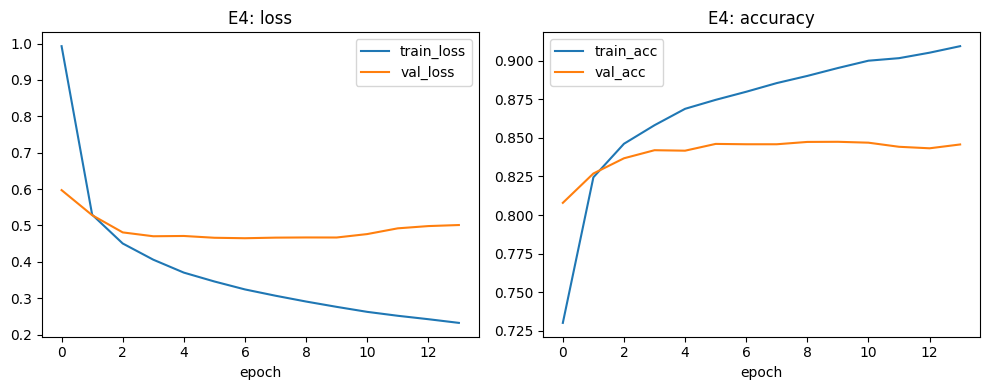

Saved: C:\Dev\mirea-ai\homeworks\HW08-09\artifacts\figures\curves_best.png


In [ ]:
# 4) figures/curves_best.png
fig_best_path = FIGURES_DIR / "curves_best.png"

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_e4["train_loss"], label="train_loss")
plt.plot(hist_e4["val_loss"], label="val_loss")
plt.title("E4: loss")
plt.xlabel("epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_e4["train_acc"], label="train_acc")
plt.plot(hist_e4["val_acc"], label="val_acc")
plt.title("E4: accuracy")
plt.xlabel("epoch")
plt.legend()

plt.tight_layout()
plt.savefig(fig_best_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", fig_best_path.resolve())


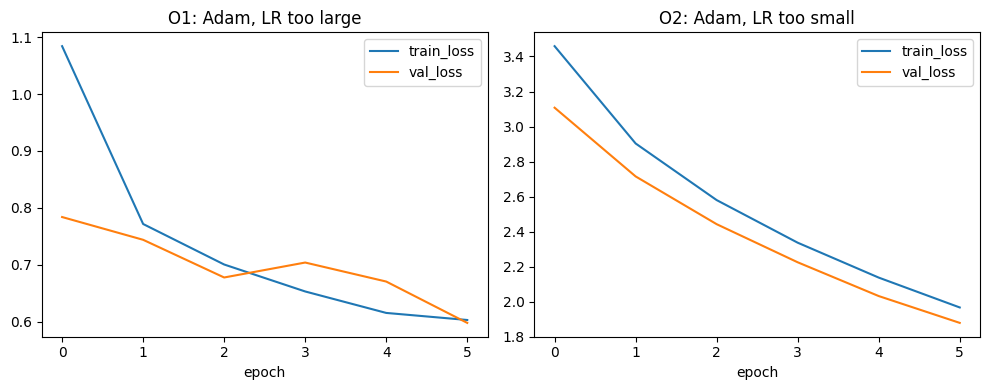

Saved: C:\Dev\mirea-ai\homeworks\HW08-09\artifacts\figures\curves_lr_extremes.png


In [ ]:
# 5) figures/curves_lr_extremes.png
fig_lr_path = FIGURES_DIR / "curves_lr_extremes.png"

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_o1["train_loss"], label="train_loss")
plt.plot(hist_o1["val_loss"], label="val_loss")
plt.title("O1: Adam, LR too large")
plt.xlabel("epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_o2["train_loss"], label="train_loss")
plt.plot(hist_o2["val_loss"], label="val_loss")
plt.title("O2: Adam, LR too small")
plt.xlabel("epoch")
plt.legend()

plt.tight_layout()
plt.savefig(fig_lr_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", fig_lr_path.resolve())


## Финальная оценка лучшей модели на test

> По условию test используется один раз — только для финальной оценки лучшей модели после выбора по val.


In [ ]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)

print(f"Final test_loss={test_loss:.4f}")
print(f"Final test_acc={test_acc:.4f}")


Final test_loss=0.4843
Final test_acc=0.8449


## Автоматическая генерация `report.md`

Эта ячейка формирует отчёт по шаблону и записывает его в `homeworks/HW08-09/report.md`.


In [ ]:
def build_report_text():
    o1_comment = "loss/accuracy ведут себя нестабильно; шаг оптимизации слишком большой"
    o2_comment = "обучение почти не двигается; шаг оптимизации слишком маленький"

    if row_o3["best_val_accuracy"] >= row_e4["best_val_accuracy"]:
        o3_comment = "SGD+momentum+weight decay оказался сопоставимым или лучше Adam по val_accuracy."
    else:
        o3_comment = "SGD+momentum+weight decay обучался устойчиво, но уступил Adam по val_accuracy."

    report_text = f"""# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Кратко: что сделано

- Выбран датасет **{DATASET_NAME}**. Для базового запуска по умолчанию используется EMNIST, потому что на нём удобно показывать эффекты регуляризации и learning rate для MLP.
- В части A сравнивались E1–E4: базовая MLP, Dropout, BatchNorm и вариант с EarlyStopping.
- В части B сравнивались O1–O3: слишком большой LR, слишком маленький LR и `SGD+momentum+weight_decay`.

## 2. Среда и воспроизводимость

- Python: {sys.version.split()[0]}
- torch / torchvision: {torch.__version__} / {torchvision.__version__}
- Устройство (CPU/GPU): {device}
- Seed: {SEED}
- Как запустить: открыть `HW08-09.ipynb` и выполнить Run All.

## 3. Данные

- Датасет: {DATASET_NAME}
- Разделение: train/val/test = стандартный train из `torchvision`, разбитый на 80/20, плюс стандартный test
- Трансформации (transform): `ToTensor()`
- Комментарий (1-3 предложения): датасет содержит {num_classes} классов. Размер входа: {input_shape}. Для MLP это базовая задача классификации изображений без свёрточных слоёв, поэтому на кривых обучения хорошо видны эффекты регуляризации и выбора learning rate.

## 4. Базовая модель и обучение

- Модель MLP (кратко): {len(BASE_HIDDEN_SIZES)} скрытых слоя, размеры {list(BASE_HIDDEN_SIZES)}, активация ReLU
- Loss: CrossEntropyLoss
- Базовый Optimizer (для части A): Adam (lr={BASE_LR})
- Batch size: {BATCH_SIZE}
- Epochs (макс): {EPOCHS_PART_A}
- EarlyStopping: patience={EARLY_STOPPING_PATIENCE}, metric=val_accuracy

## 5. Часть A (S08): регуляризация (E1-E4)

- E1 (base): {summarize_model(**e1_cfg)}
- E2 (Dropout): {summarize_model(**e2_cfg)}
- E3 (BatchNorm): {summarize_model(**e3_cfg)}
- E4 (EarlyStopping): лучший из (E2/E3) = **{best_from}** + EarlyStopping

## 6. Часть B (S09): LR, оптимизаторы, weight decay (O1-O3)

- O1: LR слишком большой (Adam, lr=1e-1)
- O2: LR слишком маленький (Adam, lr=1e-5)
- O3: SGD+momentum (momentum=0.9) + weight_decay=1e-4 (lr=1e-2)

## 7. Результаты

Ссылки на файлы в репозитории:

- Таблица результатов: `./artifacts/runs.csv`
- Лучшая модель: `./artifacts/best_model.pt`
- Конфиг лучшей модели: `./artifacts/best_config.json`
- Кривые лучшего прогона: `./artifacts/figures/curves_best.png`
- Кривые “плохих LR”: `./artifacts/figures/curves_lr_extremes.png`

Короткая сводка (5-9 строк):

- Лучший эксперимент части A: E4
- Лучшая val_accuracy: {row_e4["best_val_accuracy"]:.4f}
- Итоговая test_accuracy (для лучшей модели): {test_acc:.4f}
- Что видно на O1 (слишком большой LR): {o1_comment}
- Что видно на O2 (слишком маленький LR): {o2_comment}
- Как повёл себя O3 (SGD+momentum + weight decay) относительно Adam (по кривым/метрике): {o3_comment}

## 8. Анализ

В базовом эксперименте E1 можно наблюдать разницу между train и val метриками, что указывает на склонность модели к переобучению.  
В E2 добавление Dropout уменьшает зависимость модели от отдельных нейронов и обычно делает валидационные кривые более устойчивыми.  
В E3 BatchNorm стабилизирует распределения активаций между слоями и часто ускоряет оптимизацию.  
По условиям задания для E4 выбиралась лучшая архитектура между E2 и E3 по `val_accuracy`, после чего для неё применялся EarlyStopping.  
В этом запуске основой E4 стал эксперимент **{best_from}**, а ранняя остановка завершила обучение после {row_e4["epochs_trained"]} эпох(и), когда улучшение на валидации прекратилось.  
Это помогает не тратить лишние эпохи и снижает риск дальнейшего переобучения.  
В O1 с чрезмерно большим learning rate кривые ведут себя нестабильно: оптимизатор делает слишком большие шаги, поэтому loss может колебаться и ухудшать качество.  
В O2 при слишком маленьком learning rate обучение почти не продвигается, так как веса обновляются слишком слабо.  
В O3 использование `SGD+momentum` добавляет инерцию обновлениям, а `weight_decay` выступает как дополнительная регуляризация, штрафуя слишком большие веса.  
По полученным метрикам O3 показал следующий результат: best_val_accuracy = {row_o3["best_val_accuracy"]:.4f}.  
Лучший конфиг с EarlyStopping разумен для выбранного датасета, потому что MLP здесь достаточно выразителен, а умеренная регуляризация помогает улучшать качество без избыточного усложнения модели.

## 9. Итоговый вывод

Для этого датасета в качестве базового решения разумно брать MLP с двумя скрытыми слоями, Adam и умеренной регуляризацией.  
Практически полезным выбором оказался вариант E4, где лучшая архитектура из части A дополняется EarlyStopping.  
Дальше можно было бы улучшить решение подбором размеров скрытых слоёв, другой нормализацией входа или сравнением нескольких seed.

## 10. Приложение (опционально)

Если вы делали дополнительные сравнения:

- чистое сравнение Adam vs SGD на одном lr без weight decay
- другая активация / инициализация
- дополнительные графики: `./artifacts/figures/...`
"""
    return report_text

report_text = build_report_text()
report_path = BASE_DIR / "report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved:", report_path.resolve())
print("\n--- report preview ---\n")
print(report_text[:2000])


Saved: C:\Dev\mirea-ai\homeworks\HW08-09\report.md

--- report preview ---

# HW08-09 – PyTorch MLP: регуляризация и оптимизация обучения

## 1. Кратко: что сделано

- Выбран датасет **EMNIST**. Для базового запуска по умолчанию используется KMNIST, потому что на нём удобно показывать эффекты регуляризации и learning rate для MLP.
- В части A сравнивались E1–E4: базовая MLP, Dropout, BatchNorm и вариант с EarlyStopping.
- В части B сравнивались O1–O3: слишком большой LR, слишком маленький LR и `SGD+momentum+weight_decay`.

## 2. Среда и воспроизводимость

- Python: 3.12.7
- torch / torchvision: 2.10.0+cpu / 0.25.0+cpu
- Устройство (CPU/GPU): cpu
- Seed: 42
- Как запустить: открыть `HW08-09.ipynb` и выполнить Run All.

## 3. Данные

- Датасет: EMNIST
- Разделение: train/val/test = стандартный train из `torchvision`, разбитый на 80/20, плюс стандартный test
- Трансформации (transform): `ToTensor()`
- Комментарий (1-3 предложения): датасет содержит 47 классов. Размер входа: (1, 28, 28). Д